# Module — Correlation, Linear Regression, Beta, and Alpha
## Notebook 4 (statsmodels edition): From pairs of stocks to the market model

**This is a variant of the earlier teaching notebook** (`04_Correlation_Regression_Beta_Alpha_Teaching.ipynb`). The content and pedagogy are the same; the difference is the regression API:

- The earlier version used **`scipy.stats.linregress`** — a purpose-built single-predictor OLS wrapper.
- This version uses **`statsmodels.formula.api.ols`** — the same library we use in Notebook 5 for multi-factor regressions. Using statsmodels here gives continuity with Notebook 5 and introduces the standard econometric `.summary()` output earlier in the course.

The mathematical results are identical (both are OLS). The summary tables are richer.

- **Section A — Correlation** between SBI, Yes Bank, and the Sensex (weekly returns).
- **Section B — Beta and Alpha** via the market model (SBI, Yes Bank vs Sensex).

Both sections work with **weekly returns** (Friday-close). The risk-free rate is **6.5% per year**, converted to a weekly rate by compounding: $r_f^{\text{weekly}} = (1 + 0.065)^{1/52} - 1 \approx 0.001213$.

Step-by-step; no user-defined functions in the narrative.


## 0. Imports and constants

New in this variant: `statsmodels.api` and `statsmodels.formula.api`.


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

import statsmodels.api as sm
import statsmodels.formula.api as smf

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 4)
pd.set_option('display.precision', 4)

## 1. Load the data and build weekly returns


### 1.1  Load SBI, Yes Bank, Sensex


In [ ]:
sbi = pd.read_csv('datasets/daily/sbi.csv')
sbi['Date'] = pd.to_datetime(sbi['Date'], format='%d-%B-%Y')
sbi = sbi.sort_values('Date').set_index('Date')

yesbank = pd.read_csv('datasets/daily/YesBank.csv')
yesbank['Date'] = pd.to_datetime(yesbank['Date'], format='%d-%B-%Y')
yesbank = yesbank.sort_values('Date').set_index('Date')

sensex = pd.read_csv('datasets/daily/bse.csv')
sensex['Date'] = pd.to_datetime(sensex['Date'], format='%d-%B-%Y')
sensex = sensex.sort_values('Date').set_index('Date')

print(f'SBI rows:     {len(sbi)}')
print(f'Yes Bank rows: {len(yesbank)}')
print(f'Sensex rows:  {len(sensex)}')


SBI rows:     242
Yes Bank rows: 242
Sensex rows:  243


### 1.2  Friday-close weekly returns for all three, aligned into one DataFrame


In [ ]:
sbi_weekly     = sbi['Close Price'].resample('W-FRI').last().pct_change().dropna()
yesbank_weekly = yesbank['Close Price'].resample('W-FRI').last().pct_change().dropna()
sensex_weekly  = sensex['Close'].resample('W-FRI').last().pct_change().dropna()

returns = pd.DataFrame({
    'SBI':     sbi_weekly,
    'YesBank': yesbank_weekly,
    'Sensex':  sensex_weekly,
}).dropna()

print(f'Aligned weekly returns: n = {len(returns)}')
returns.head()


Aligned weekly returns: n = 51


,SBI,YesBank,Sensex
Date,,,
2025-05-09,-0.0258,0.1293,-0.0130
2025-05-16,0.0160,0.0770,0.0362
2025-05-23,-0.0018,-0.0181,-0.0074
2025-05-30,0.0278,0.0151,-0.0033
2025-06-06,0.0006,-0.0289,0.0091


### 1.3  Excess returns — subtract the weekly risk-free rate


In [ ]:
# Risk-free rate — 6.5% per year, converted to a weekly rate by COMPOUNDING.
RF_ANNUAL = 0.065
RF_WEEKLY = (1 + RF_ANNUAL) ** (1/52) - 1

print(f'Annual risk-free rate:  {RF_ANNUAL:.6f}  ({RF_ANNUAL*100:.4f}%)')
print(f'Weekly risk-free rate:  {RF_WEEKLY:.6f}  ({RF_WEEKLY*100:.4f}% per week)')

Annual risk-free rate:  0.065000  (6.5000%)
Weekly risk-free rate:  0.001212  (0.1212% per week)


In [ ]:
excess = returns - RF_WEEKLY
excess.columns = ['SBI_ex', 'YesBank_ex', 'Sensex_ex']

print(f'Risk-free weekly rate (compounded): {RF_WEEKLY:.6f}')
print('\nMean excess returns (these are what CAPM cares about):')
print(excess.mean().round(6))


Risk-free weekly rate (compounded): 0.001212

Mean excess returns (these are what CAPM cares about):
SBI_ex        0.0057
YesBank_ex    0.0018
Sensex_ex    -0.0016
dtype: float64


---

# SECTION A — Correlation

We have three weekly return series: SBI, Yes Bank, and the Sensex. How are they related?

**Correlation** — symmetric, unit-free, bounded on $[-1, +1]$. It measures the strength of linear association without committing to a direction of cause. We'll compute it for all three pairs (stock-vs-stock and each stock vs the market) and use it as the natural lead-in to Section B, where the *regression* of stock on market gives us beta and alpha.


## A.1  Visual first — the scatter plot


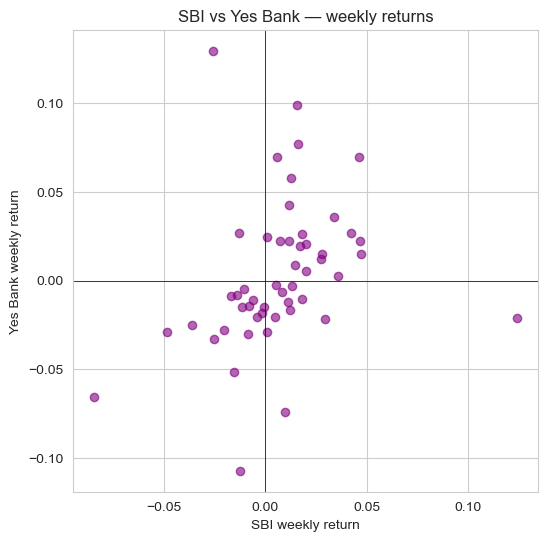

In [ ]:
fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(returns['SBI'], returns['YesBank'], alpha=0.6, color='purple')
ax.axhline(0, color='black', lw=0.5)
ax.axvline(0, color='black', lw=0.5)
ax.set_xlabel('SBI weekly return')
ax.set_ylabel('Yes Bank weekly return')
ax.set_title('SBI vs Yes Bank — weekly returns')
plt.show()


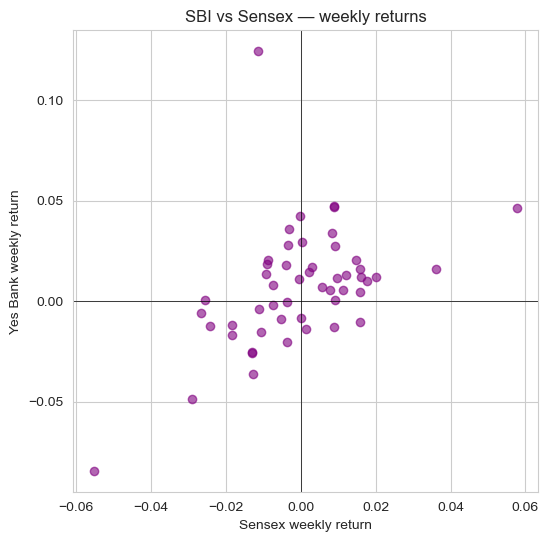

In [ ]:
fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(returns['Sensex'], returns['SBI'], alpha=0.6, color='purple')
ax.axhline(0, color='black', lw=0.5)
ax.axvline(0, color='black', lw=0.5)
ax.set_xlabel('Sensex weekly return')
ax.set_ylabel('Yes Bank weekly return')
ax.set_title('SBI vs Sensex — weekly returns')
plt.show()

## A.2  Correlation — symmetric, unit-free

$$
\rho = \frac{\text{Cov}(X, Y)}{\sigma_X \sigma_Y}
$$


### A.2.2  Correlation

In [ ]:
print(f'rho (pandas):    {returns["SBI"].corr(returns["Sensex"]):+.4f}')

rho (pandas):    +0.4811


### A.2.3  Full 3×3 correlation matrix


In [ ]:
returns[['SBI', 'YesBank', 'Sensex']].corr()


,SBI,YesBank,Sensex
SBI,1.0000,0.2852,0.4811
YesBank,0.2852,1.0000,0.4791
Sensex,0.4811,0.4791,1.0000


---

# SECTION B — Beta and Alpha: the market model

The **market model** regresses a stock's excess return on the market's excess return:

$$
r_i^{\text{ex}} \;=\; \alpha_i \;+\; \beta_i \cdot r_m^{\text{ex}} \;+\; \varepsilon_i
$$

- $\beta_i$ (**systematic risk**) — how much stock $i$ moves per unit move in the market.
- $\alpha_i$ (**Jensen's alpha**) — risk-adjusted excess return.
- $\varepsilon_i$ — idiosyncratic residual.

We'll compute $\beta$ two ways — covariance formula first (pure math), then statsmodels (standard tool) — and compare.

Market proxy: Sensex. Stocks: SBI and Yes Bank. All returns weekly and in **excess form** (subtracted the weekly risk-free rate).


### Quick sanity check — what do we have?


In [ ]:
excess.head()

,SBI_ex,YesBank_ex,Sensex_ex
Date,,,
2025-05-09,-0.0270,0.1281,-0.0142
2025-05-16,0.0148,0.0758,0.0350
2025-05-23,-0.0030,-0.0193,-0.0086
2025-05-30,0.0266,0.0139,-0.0045
2025-06-06,-0.0007,-0.0301,0.0078


## B.1 Beta and alpha by OLS regression — SBI

Same data, now fit as an explicit OLS regression with an intercept. `statsmodels` gives us α, β, their standard errors, t-stats, p-values, and R² in one call.


In [ ]:
res_sbi = smf.ols('SBI_ex ~ Sensex_ex', data=excess).fit()
print(res_sbi.summary())

                            OLS Regression Results                            
Dep. Variable:                 SBI_ex   R-squared:                       0.231
Model:                            OLS   Adj. R-squared:                  0.216
Method:                 Least Squares   F-statistic:                     14.76
Date:                Sun, 26 Apr 2026   Prob (F-statistic):           0.000352
Time:                        11:41:27   Log-Likelihood:                 114.32
No. Observations:                  51   AIC:                            -224.6
Df Residuals:                      49   BIC:                            -220.8
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      0.0070      0.004      1.885      0.0

They agree — as algebra guarantees. The statsmodels view additionally gives us:

- the **intercept** $\alpha$ and its standard error (the covariance formula doesn't),
- a **confidence interval** and a **p-value** for every coefficient,
- a full set of regression diagnostics from `.summary()`.


## B.3  Visualise — SBI scatter with fitted line


In [ ]:
alpha_sbi    = res_sbi.params['Intercept']
beta_sbi     = res_sbi.params['Sensex_ex']
alpha_sbi_se = res_sbi.bse['Intercept']
beta_sbi_se  = res_sbi.bse['Sensex_ex']
r2_sbi      = res_sbi.rsquared

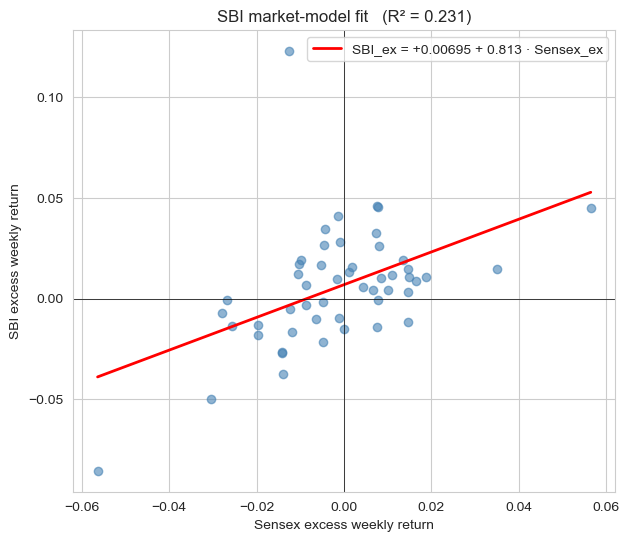

In [ ]:
x_grid = np.linspace(excess['Sensex_ex'].min(), excess['Sensex_ex'].max(), 100)
y_fit  = alpha_sbi + beta_sbi * x_grid

fig, ax = plt.subplots(figsize=(7, 6))
ax.scatter(excess['Sensex_ex'], excess['SBI_ex'], alpha=0.6, color='steelblue')
ax.plot(x_grid, y_fit, 'r-', linewidth=2,
        label=f'SBI_ex = {alpha_sbi:+.5f} + {beta_sbi:.3f} · Sensex_ex')
ax.axhline(0, color='black', lw=0.5)
ax.axvline(0, color='black', lw=0.5)
ax.set_xlabel('Sensex excess weekly return')
ax.set_ylabel('SBI excess weekly return')
ax.set_title(f'SBI market-model fit   (R² = {r2_sbi:.3f})')
ax.legend()
plt.show()


## B.4  Same for Yes Bank


In [ ]:
# OLS regression
res_yb = smf.ols('YesBank_ex ~ Sensex_ex', data=excess).fit()
print(res_yb.summary())

                            OLS Regression Results                            
Dep. Variable:             YesBank_ex   R-squared:                       0.230
Model:                            OLS   Adj. R-squared:                  0.214
Method:                 Least Squares   F-statistic:                     14.60
Date:                Sun, 26 Apr 2026   Prob (F-statistic):           0.000375
Time:                        11:41:27   Log-Likelihood:                 96.955
No. Observations:                  51   AIC:                            -189.9
Df Residuals:                      49   BIC:                            -186.0
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      0.0035      0.005      0.682      0.4

In [ ]:
alpha_yb    = res_yb.params['Intercept']
beta_yb     = res_yb.params['Sensex_ex']
alpha_yb_se = res_yb.bse['Intercept']
beta_yb_se  = res_yb.bse['Sensex_ex']
r2_yb       = res_yb.rsquared

## B.5  Head-to-head — SBI vs Yes Bank

**Annualising alpha**. Because we converted the risk-free rate by compounding, we annualise α the same way: $(1 + \alpha_{\text{weekly}})^{52} - 1$.


In [ ]:
market_model_table = pd.DataFrame({
    'alpha_weekly':     [alpha_sbi,   alpha_yb],
    'alpha_SE':         [alpha_sbi_se, alpha_yb_se],
    'alpha_p':          [res_sbi.pvalues['Intercept'], res_yb.pvalues['Intercept']],
    'beta':             [beta_sbi,    beta_yb],
    'beta_SE':          [beta_sbi_se, beta_yb_se],
    'R²':               [r2_sbi,      r2_yb],
    'alpha_annualised': [(1 + alpha_sbi)**52 - 1, (1 + alpha_yb)**52 - 1],
}, index=['SBI', 'YesBank'])
market_model_table


,alpha_weekly,alpha_SE,alpha_p,beta,beta_SE,R²,alpha_annualised
SBI,0.0070,0.0037,0.0654,0.8130,0.2116,0.2315,0.4337
YesBank,0.0035,0.0052,0.4982,1.1366,0.2975,0.2296,0.2016


**How to read this table**

- **β > 1** → aggressive (moves more than the market). **β < 1** → defensive. **β ≈ 1** → market-like.
- **R²** → fraction of the stock's variance explained by the market.
- **α annualised** → compounded yearly excess return after removing systematic risk.
- **p-values** — are α and β statistically distinguishable from zero?


## B.6  Is alpha significantly different from zero?

$H_0: \alpha = 0$ vs $H_1: \alpha \neq 0$.

$$
t = \frac{\hat{\alpha}}{\text{SE}(\hat{\alpha})}
\quad \text{distributed as } t_{n - 2} \text{ under } H_0.
$$

Degrees of freedom are $n - 2$ because two coefficients were estimated.


### B.6.2  One sample test using `statsmodels`

statsmodels already computed these — in fact they're printed in the `.summary()` table from §B.2. We can pull them out directly.


In [ ]:
print(f'SBI alpha test (from statsmodels):')
print(f'  t     = {res_sbi.tvalues["Intercept"]:+.3f}')
print(f'  p     = {res_sbi.pvalues["Intercept"]:.4f}')


SBI alpha test (from statsmodels):
  t     = +1.885
  p     = 0.0654


### B.6.3  Yes Bank — and the decision rule


In [ ]:
alpha_level = 0.05
for label, res in [('SBI',      res_sbi),
                   ('YesBank',  res_yb)]:
    t_a = res.tvalues['Intercept']
    p_a = res.pvalues['Intercept']
    decision = 'REJECT alpha=0' if p_a < alpha_level else 'FAIL TO REJECT'
    print(f'{label:8s}:  t = {t_a:+.3f}   p = {p_a:.4f}   at alpha={alpha_level}: {decision}')


SBI     :  t = +1.885   p = 0.0654   at alpha=0.05: FAIL TO REJECT
YesBank :  t = +0.682   p = 0.4982   at alpha=0.05: FAIL TO REJECT


**Key realisation.** With ~50 weekly observations, Jensen's α is rarely statistically significant — the standard error is comparable to the point estimate.

> **Intermediate exercise B.1**
>
> Test $H_0: \beta = 1$ (not $\beta = 0$) for SBI. statsmodels has a built-in way to do this via `res_sbi.t_test('Sensex_ex = 1')`. Try it. The manual equivalent is $t = (\hat{\beta} - 1) / \text{SE}(\hat{\beta})$ with $t_{n-2}$ reference. Do they match?


---

## Summary

**Correlation vs regression**

- Correlation is symmetric, unit-free, bounded.
- Regression is one-sided, has units, and gives us α / β.
- $R^2 = \rho^2$ is the one bridging identity.
- Direction matters: $\text{slope}(Y \sim X) \times \text{slope}(X \sim Y) = \rho^2$.

**Beta and alpha (via statsmodels OLS)**

- **β** = slope of the market-model regression = Cov(stock_ex, market_ex) / Var(market_ex).
- **α** = intercept of the market-model regression = mean(stock_ex) − β × mean(market_ex).
- statsmodels' `.summary()` gives α, β, standard errors, t-stats, p-values, R², and Adjusted R² in one call — and this is the natural tool to continue with for the Fama-French 3-factor regressions in Notebook 5.

**Rate conversion**

- Convert annual rates to weekly by compounding: $(1 + r_a)^{1/52} - 1$. Simple division is close but not self-consistent.

**What β is invariant to**

- Adding a constant (like subtracting the risk-free rate) doesn't change the covariance or the variance, so β is **unchanged** whether we use raw or excess returns. But α *does* change — which is why CAPM is defined in excess-return space.
